# Customer Churn Prediction - Model Training

##  Logistic Regression

In this notebook, we train and evaluate a Logistic Regression model
to predict whether a customer is likely to churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [3]:
df = pd.read_csv("../data/customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7032, 21)

In [5]:
df = df.drop("customerID", axis=1)

In [6]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\A C E R\AppData\Local\Temp\ipykernel_3012\1874343763.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [9]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [10]:
X.shape

(7032, 30)

In [11]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [14]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [15]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [16]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = log_model.predict(X_test)

In [18]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [19]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8053
Precision: 0.6515
Recall:    0.5749
F1 Score:  0.6108
ROC-AUC:   0.8361


In [21]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



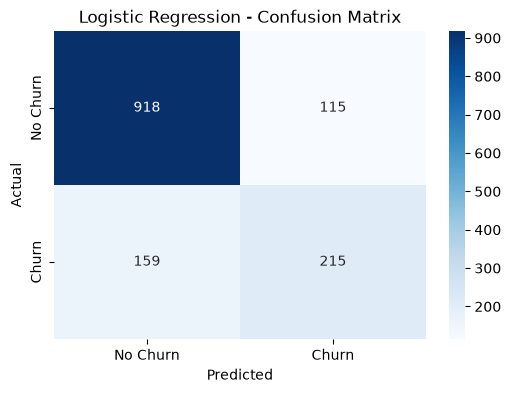

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

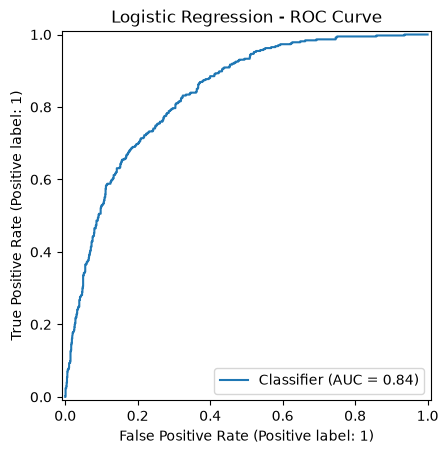

In [23]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

## Logistic Regression Results

The Logistic Regression model was used as the baseline model for customer churn prediction.

### Model Performance

- Accuracy: 80.53%
- Precision: 65.15%
- Recall: 57.49%
- F1-score: 61.08%
- ROC-AUC: 0.8361

### Observation

The Logistic Regression model achieved an overall accuracy of 80.53%.

The precision of 65.15% indicates that, among customers predicted to churn, about 65% actually churned. The recall of 57.49% shows that the model identified about 57% of the customers who actually churned.

The F1-score of 61.08% reflects the balance between precision and recall. The ROC-AUC score of 0.8361 indicates that the model has useful ability to distinguish between churn and non-churn customers.

Since the churn class is smaller than the non-churn class, accuracy alone is not sufficient for evaluating the model. Therefore, precision, recall, F1-score, and ROC-AUC are also considered.

#  Decision Tree and Random Forest

In this section, we train and evaluate Decision Tree and Random Forest
classifiers for customer churn prediction.

Their performance will later be compared with the Logistic Regression
baseline model.

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [26]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [28]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_prob)

print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")
print(f"ROC-AUC:   {dt_roc_auc:.4f}")

Accuracy:  0.7783
Precision: 0.5807
Recall:    0.5963
F1 Score:  0.5884
ROC-AUC:   0.8195


In [29]:
print(classification_report(
    y_test,
    dt_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



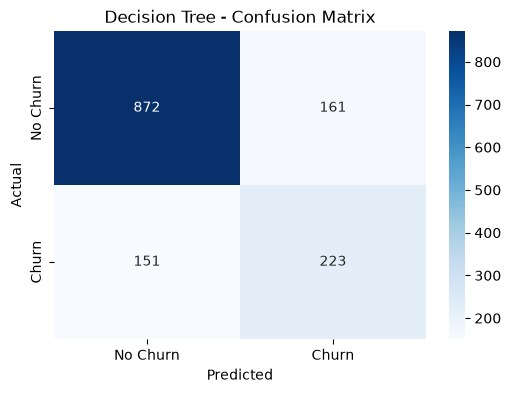

In [30]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

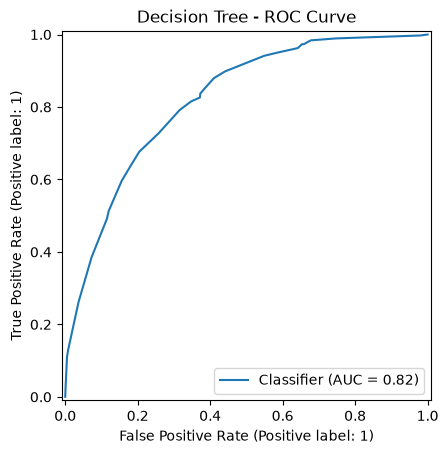

In [31]:
RocCurveDisplay.from_predictions(
    y_test,
    dt_prob
)

plt.title("Decision Tree - ROC Curve")
plt.show()

## Random Forest

Random Forest combines multiple decision trees to make predictions.
The model is evaluated using the same test dataset and metrics used for
Logistic Regression and Decision Tree.

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [34]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.7903
Precision: 0.6321
Recall:    0.5053
F1 Score:  0.5617
ROC-AUC:   0.8344


In [37]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



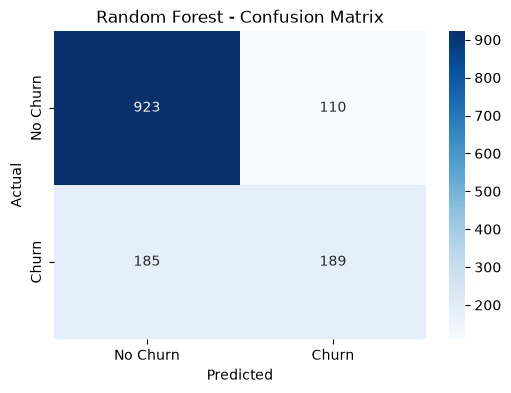

In [38]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

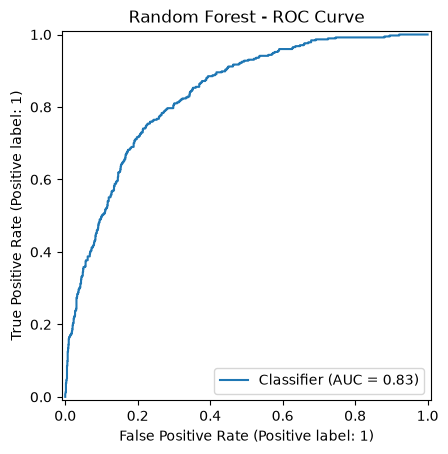

In [39]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("Random Forest - ROC Curve")
plt.show()

## Results

### Decision Tree

- Accuracy: 77.83%
- Precision: 58.07%
- Recall: 59.63%
- F1-score: 58.84%
- ROC-AUC: 0.8195

### Random Forest

- Accuracy: 79.03%
- Precision: 63.21%
- Recall: 50.53%
- F1-score: 56.17%
- ROC-AUC: 0.8344

### Observations

The Decision Tree and Random Forest models were evaluated using the same
training and testing data used for the Logistic Regression baseline.

The Decision Tree achieved an accuracy of 77.83% and identified
59.63% of actual churn customers, as reflected by its recall.

The Random Forest achieved a higher accuracy of 79.03% and precision
of 63.21%, but its recall was lower at 50.53%. This means it identified
a smaller proportion of the customers who actually churned.

The Random Forest achieved a ROC-AUC of 0.8344, compared with 0.8195
for the Decision Tree, indicating stronger overall discrimination between
churn and non-churn customers across classification thresholds.

These results will be compared with the Logistic Regression baseline in the
next stage using multiple evaluation metrics rather than accuracy alone.

# Day 9 - Model Comparison and Evaluation

In this section, the Logistic Regression, Decision Tree, and Random Forest
models are compared using multiple evaluation metrics.

Since the churn dataset is moderately imbalanced, model performance is
evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC rather
than relying only on accuracy.

In [40]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510
2,Random Forest,0.790334,0.632107,0.505348,0.561664,0.834433


In [41]:
display_results = model_results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    display_results[col] = (display_results[col] * 100).round(2)

display_results["ROC-AUC"] = display_results["ROC-AUC"].round(4)

display_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,80.53,65.15,57.49,61.08,0.8361
1,Decision Tree,77.83,58.07,59.63,58.84,0.8195
2,Random Forest,79.03,63.21,50.53,56.17,0.8344


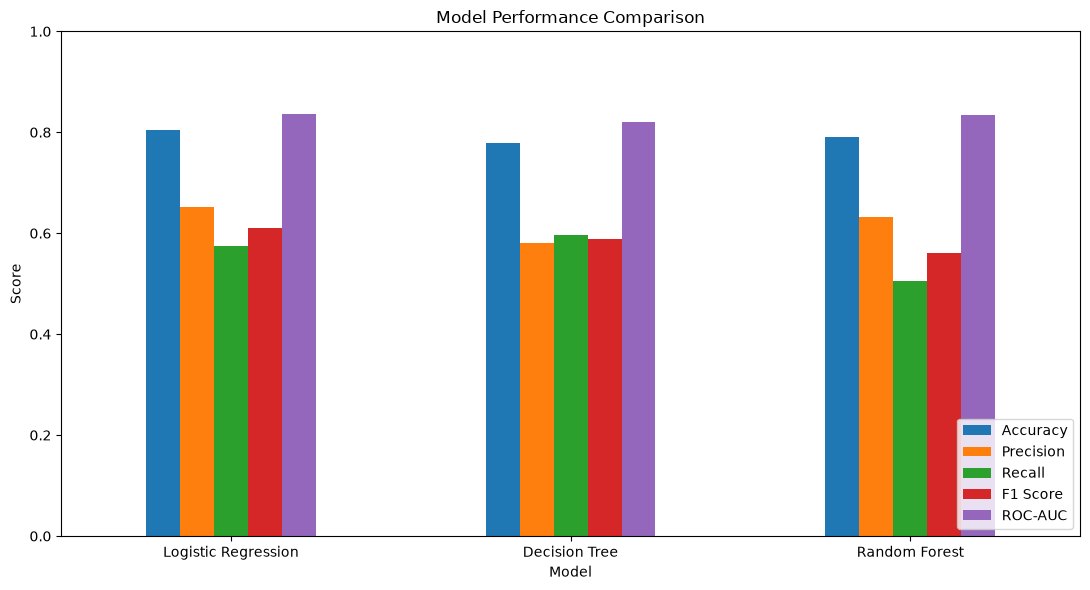

In [42]:
plot_results = model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

plot_results.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

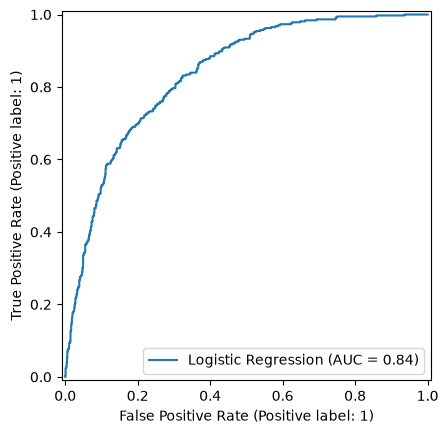

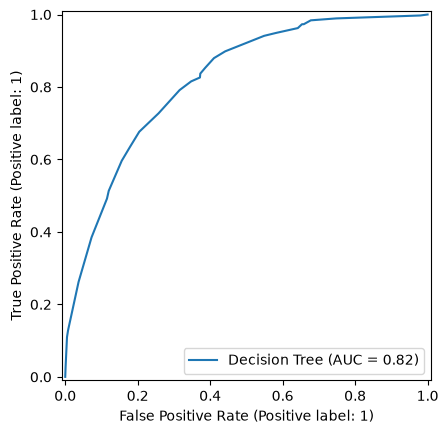

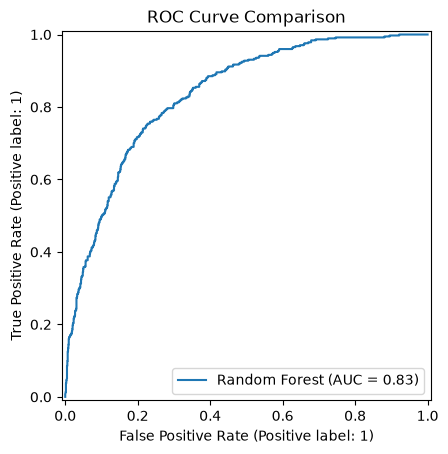

In [43]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    dt_prob,
    name="Decision Tree"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

## Model Comparison Findings

Three machine learning models were evaluated using the same train/test split.

- Logistic Regression achieved **80.53% accuracy**, **61.08% F1-score**, and
  **0.8361 ROC-AUC**.
- Decision Tree achieved **77.83% accuracy**, **58.84% F1-score**, and
  **0.8195 ROC-AUC**.
- Random Forest achieved **79.03% accuracy**, **56.17% F1-score**, and
  **0.8344 ROC-AUC**.
- Decision Tree produced the highest recall among the three models at
  **59.63%**, while Logistic Regression produced a recall of **57.49%**.
- The models show different trade-offs between identifying more churn customers
  and reducing incorrect churn predictions.

These results provide baseline performance for the three models. Model tuning
will be performed next to investigate whether performance can be improved.